<a href="https://colab.research.google.com/github/geopayme/AstroPhysics/blob/main/QITFT_Module4_Quantization_Commutator_Potential_Fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📘 ∞-Tensor Canonical Commutator [ψ(x), π(y)] = i δ(x−y):


Eq(0, I*DiracDelta(x - y))


📘 Euler–Lagrange Equation with Potential V(ψ) = m²ψ² + λψ⁴:


Eq(4*lambda*psi(t)**3 + 2*m**2*psi(t) + 1.0*Derivative(psi(t), (t, 2)), 0)

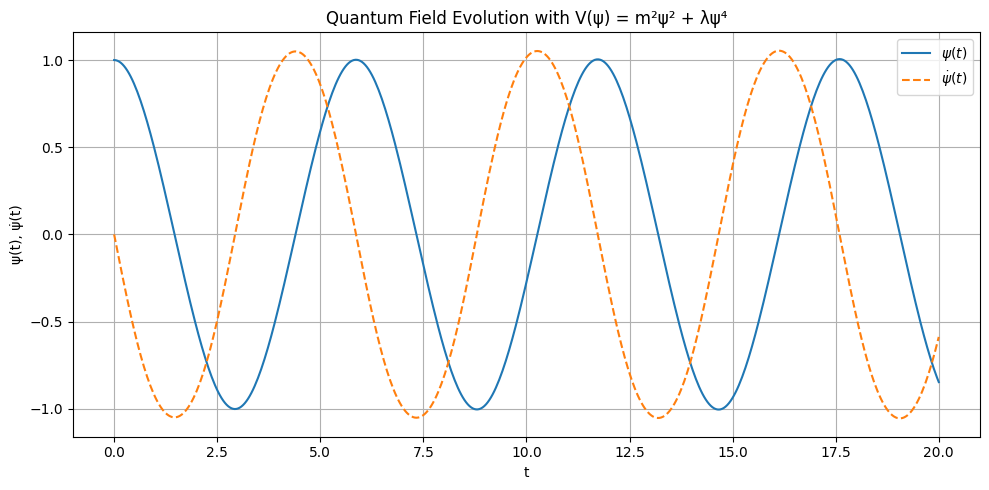

In [1]:

# 📘 QITFT — Module 4: Quantization, ∞-Commutators, and Example Potential (Fixed)

!pip install sympy numpy matplotlib --quiet

from sympy import symbols, Function, Derivative, Eq, dsolve, simplify, DiracDelta, I
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ------------------------------------------------------------
# 🎯 Field Quantization Setup: Define Commutator [ψ(x), π(y)]
# ------------------------------------------------------------

x, y = symbols('x y')
psi = Function('psi')(x)
pi = Function('pi')(y)

commutator = Eq(psi * pi - pi * psi, I * DiracDelta(x - y))
print("📘 ∞-Tensor Canonical Commutator [ψ(x), π(y)] = i δ(x−y):")
display(commutator)

# ------------------------------------------------------------
# 🧪 Example Potential: V(ψ) = m² ψ² + λ ψ⁴
# ------------------------------------------------------------

t = symbols('t')
psi = Function('psi')(t)
m, lam = symbols('m lambda')

# Define the equation of motion (E-L result in flat spacetime 1D)
V = m**2 * psi**2 + lam * psi**4
L = 0.5 * Derivative(psi, t)**2 - V

# Euler-Lagrange equation: d²ψ/dt² + dV/dψ = 0
dL_dpsi = L.diff(psi)
dL_d_dpsi = L.diff(Derivative(psi, t))
d_dt = Derivative(dL_d_dpsi, t)
EL_eq = simplify(d_dt - dL_dpsi)

print("\n📘 Euler–Lagrange Equation with Potential V(ψ) = m²ψ² + λψ⁴:")
display(Eq(EL_eq, 0))

# ------------------------------------------------------------
# 🧮 Numerical Solution
# ------------------------------------------------------------

# Define m and λ
m_val = 1.0
lam_val = 0.1

# Define ψ'' + m²ψ + 2λψ³ = 0
def field_eq(t, y):
    psi, dpsi = y
    d2psi = -m_val**2 * psi - 2 * lam_val * psi**3
    return [dpsi, d2psi]

# Initial conditions: ψ(0) = 1.0, ψ'(0) = 0.0
y0 = [1.0, 0.0]
t_span = (0, 20)
t_eval = np.linspace(*t_span, 500)

sol = solve_ivp(field_eq, t_span, y0, t_eval=t_eval)

# ------------------------------------------------------------
# 📊 Plotting the Field Evolution
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.plot(sol.t, sol.y[0], label=r"$\psi(t)$")
plt.plot(sol.t, sol.y[1], label=r"$\dot{\psi}(t)$", linestyle="--")
plt.title("Quantum Field Evolution with V(ψ) = m²ψ² + λψ⁴")
plt.xlabel("t")
plt.ylabel("ψ(t), ψ̇(t)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
